In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from vizman import viz
import os
import re 

import pickle

from config import COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap, bone_white, half_black, emp_dataset_and_experiment_pairs

In [18]:
# Generate output folder
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis")

input_folder = output_folder 

output_folder = output_folder / "04_metastability" 
output_folder.mkdir(exist_ok=True)


dataset_of_choice = "hcp_schaefer_100_dataset_gnm"
number_of_samples_each = 5

In [19]:
dict_with_all_datasets = {}


columns_to_remove = ["distance_relationship_type", "generative_rule", "num_iterations", "preferential_relationship_type", 
                         "id", "network_idx", "network_index", 
                         "mc_values_for_indiv_lags"]

for dataset_name in ["hcp_schaefer_100_dataset"]:
    
    experiment_name_gnm = "11_mst_2500_animal_0"
    base_path_gnm = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name_gnm}")
    precise_gnm_files = {
                        "fundamental": f"all_metrics_for_{experiment_name_gnm}.csv", 
                        "static": f"all_static_metrics_for_{experiment_name_gnm}_updated.csv", 
                        "dynamic": f"all_dynamic_metrics_for_{experiment_name_gnm}_updated.csv", 
                        "computational": f"all_computational_metrics_for_{experiment_name_gnm}_updated.csv", 
                        "further": f"all_further_metrics_for_{experiment_name_gnm}_updated.csv", 
                        }

    # Combine them all to one big dataframe. The indeces correspond to same entries across the different metric types, so we can easily merge them. Check first if the dfs are equally long. 
    dfs_gnm = {key: pd.read_csv(base_path_gnm / file) for key, file in precise_gnm_files.items()}
    lengths_gnm = {key: len(df) for key, df in dfs_gnm.items()}
    print(lengths_gnm)
    # They are all equally long, so we can merge them together (eta, gamma, id) 
    df_gnm = dfs_gnm["fundamental"]  # Start with the fundamental df as the base
    for key in precise_gnm_files.keys():
        if key == "fundamental":
            continue  # Skip the fundamental df since it's already our base
        print(key)
        df_gnm = df_gnm.merge(dfs_gnm[key], on=["eta", "gamma", "id"], how="left", suffixes=("", f"_{key}"))
        
    # df_gnm = pd.concat(dfs_gnm.values(), axis=1)
    # Check if there are duplicate columns after merging. If so, we can drop them - but print them first to see which ones they are.
    duplicate_columns_gnm = df_gnm.columns[df_gnm.columns.duplicated()]
    print("Attention: Duplicate entries (got removed from the 'previous' df):", duplicate_columns_gnm)
    # Drop the duplicate columns. We want to delete the ones from the "previous" df
    df_gnm = df_gnm.loc[:, ~df_gnm.columns.duplicated()]
        
    # Remove columns if all their entries are empty 
    df_gnm = df_gnm.dropna(axis=1, how="all")
    
    # # drop "repertoire_sweep_T_vec", "repertoire_sweep_sizes", "repertoire_sweep_diversities", if those columns are present in the df, since they are not relevant for the analysis and they have many missing values.
    # for col in ["repertoire_sweep_T_vec", "repertoire_sweep_sizes", "repertoire_sweep_diversities"]:
    #     if col in df_gnm.columns:
    #         df_gnm = df_gnm.drop(col, axis=1)
    #         print(f"Dropped column '{col}' from '{dataset_name}' because it had many missing values and is not relevant for the analysis.")
    #     else:
    #         print(f"Column '{col}' not found in '{dataset_name}', so it was not dropped.")

    # Remove unimportant columns
    columns_to_remove += [col for col in df_gnm.columns if col.startswith("h_params")]
    df_gnm = df_gnm.drop(columns=[col for col in columns_to_remove if col in df_gnm.columns])

    # Check the shape of the final df
    print(df_gnm.shape)

    dict_with_all_datasets[dataset_name+"_gnm"] = df_gnm
    
    

for dataset_name in emp_dataset_and_experiment_pairs:
    
    if dataset_name == "hcp_schaefer_100_dataset_gnm":
        continue  # We already processed the gnm data for this dataset, so we skip it here.
    
    # Do the same thing for the empirical data.
    experiment_name_emp = emp_dataset_and_experiment_pairs[dataset_name]
    base_path_emp = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name_emp}")
    precise_emp_files = {"static": f"metrics_2_static.csv", 
                         "dynamic": f"metrics_2_dynamic.csv",
                         "computational": f"metrics_2_computational.csv",
                         "further": f"metrics_2_further.csv"}
    
    # Combine them all to one big dataframe. The indeces correspond to same entries across the different metric types, so we can easily merge them. Check first if the dfs are equally long. 
    dfs = {key: pd.read_csv(base_path_emp / file) for key, file in precise_emp_files.items()}
    lengths = {key: len(df) for key, df in dfs.items()}
    print(lengths)
    # They are all equally long, so we can merge them on the index.
    # df = pd.concat(dfs.values(), axis=1)
    df = dfs["static"]  # Start with the static df as the base
    for key in precise_emp_files.keys():
        if key == "static":
            continue  # Skip the static df since it's already our base
        print(key)
        df = df.merge(dfs[key], left_index=True, right_index=True, how="left", suffixes=("", f"_{key}"))
    
        
    # Rename columns: strip "basic_measures_" prefix where present
    df.columns = [col.replace("basic_measures_", "") if col.startswith("basic_measures_") else col for col in df.columns]
    
    # Rename columns: strip "mc_original_" prefix where present
    df.columns = [col.replace("mc_original_", "") if col.startswith("mc_original_") else col for col in df.columns]

    # Check if there are duplicate columns after merging. If so, we can drop them - but print them first to see which ones they are.
    duplicate_columns_emp = df.columns[df.columns.duplicated()]
    print("Attention: Duplicate entries (did not get removed so far):", duplicate_columns_emp)
    # Remove exact-duplicate columns (content-identical), keep first occurrence
    cols_to_keep = []
    seen = {}
    for i, col in enumerate(df.columns):
        if col not in seen:
            seen[col] = i
            cols_to_keep.append(i)
        else:
            # Check if the duplicate column is identical in content
            if df.iloc[:, seen[col]].equals(df.iloc[:, i]):
                print(f"  -> Dropping identical duplicate column: '{col}'")
            else:
                # Keep both but rename the duplicate
                new_name = f"{col}_dup"
                df.columns.values[i] = new_name
                cols_to_keep.append(i)
                print(f"  -> Kept non-identical duplicate column '{col}' as '{new_name}'")
    df = df.iloc[:, cols_to_keep]
    
    # # drop "repertoire_sweep_T_vec", "repertoire_sweep_sizes", "repertoire_sweep_diversities", if those columns are present in the df, since they are not relevant for the analysis and they have many missing values.
    # for col in ["repertoire_sweep_T_vec", "repertoire_sweep_sizes", "repertoire_sweep_diversities"]:
    #     if col in df.columns:
    #         df = df.drop(col, axis=1)
    #         print(f"Dropped column '{col}' from '{dataset_name}' because it had many missing values and is not relevant for the analysis.")
    #     else:
    #         print(f"Column '{col}' not found in '{dataset_name}', so it was not dropped.")

            
    # Remove columns if all their entries are empty 
    df = df.dropna(axis=1, how="all")

    # if there is n_components in the df, then exclude the rows where n_components != 1 and print the row ids 
    if "n_connected_components" in df.keys():          
        # Get all rows where n_connected_components != 1; print them and exclude them
        non_singleton_components = df[df['n_connected_components'] != 1]
        indices_to_remove = non_singleton_components.index.tolist()
        if len(indices_to_remove) > 0: 
            print("⚠️ Non-singleton components. IDs that are going to be removed: ", indices_to_remove) #  "their 'network_id' or similar values:", non_singleton_components[["id", "network_index", "network_idx"]]))
            df = df[df['n_connected_components'] == 1]
        
    # Remove unimportant columns
    columns_to_remove += [col for col in df.columns if col.startswith("h_params")]
    df = df.drop(columns=[col for col in columns_to_remove if col in df.columns])


    # Check the shape of the final df   
    print(df.shape)
    dict_with_all_datasets[dataset_name] = df
    

{'fundamental': 25000, 'static': 25000, 'dynamic': 25000, 'computational': 25000, 'further': 25000}
static
dynamic
computational
further
Attention: Duplicate entries (got removed from the 'previous' df): Index([], dtype='object')
(25000, 197)
{'static': 100, 'dynamic': 100, 'computational': 100, 'further': 100}
dynamic
computational
further
Attention: Duplicate entries (did not get removed so far): Index(['global_efficiency', 'modularity', 'avg_clustering', 'avg_degree',
       'transitivity', 'wiring_cost'],
      dtype='object')
  -> Dropping identical duplicate column: 'global_efficiency'
  -> Kept non-identical duplicate column 'modularity' as 'modularity_dup'
  -> Dropping identical duplicate column: 'avg_clustering'
  -> Dropping identical duplicate column: 'avg_degree'
  -> Dropping identical duplicate column: 'transitivity'
  -> Kept non-identical duplicate column 'wiring_cost' as 'wiring_cost_dup'
(100, 190)
{'static': 1, 'dynamic': 1, 'computational': 1, 'further': 1}
dynamic

In [20]:
dict_with_all_datasets[dataset_of_choice][["repertoire_sweep_T_vec", "repertoire_sweep_sizes", "repertoire_sweep_diversities"]]

,repertoire_sweep_T_vec,repertoire_sweep_sizes,repertoire_sweep_diversities
0,"[0.01, 0.010985411419875584, 0.012067926406393...","[22, 12, 11, 18, 7, 18, 11, 14, 9, 6, 19, 11, ...","[0.19, 0.14500000000000002, 0.16, 0.17, 0.09, ..."
1,"[0.01, 0.010985411419875584, 0.012067926406393...","[7, 7, 10, 6, 11, 3, 3, 9, 10, 7, 5, 8, 8, 2, ...","[0.23, 0.28, 0.28, 0.24, 0.31, 0.29, 0.35, 0.3..."
2,"[0.01, 0.010985411419875584, 0.012067926406393...","[6, 6, 4, 5, 5, 2, 5, 9, 2, 5, 4, 14, 9, 7, 6,...","[0.35, 0.3, 0.27, 0.055, 0.445, 0.14, 0.41, 0...."
3,"[0.01, 0.010985411419875584, 0.012067926406393...","[6, 3, 14, 6, 11, 6, 13, 11, 5, 8, 11, 13, 13,...","[0.36, 0.02, 0.25, 0.37, 0.3, 0.26, 0.185, 0.1..."
4,"[0.01, 0.010985411419875584, 0.012067926406393...","[3, 9, 14, 8, 9, 12, 9, 9, 8, 9, 9, 6, 5, 13, ...","[0.24, 0.36, 0.18, 0.315, 0.315, 0.18, 0.1, 0...."
...,...,...,...
24995,"[0.01, 0.010985411419875584, 0.012067926406393...","[6, 1, 12, 10, 7, 13, 5, 6, 9, 6, 8, 12, 8, 12...","[0.28, nan, 0.34, 0.3, 0.35, 0.25, 0.120000000..."
24996,"[0.01, 0.010985411419875584, 0.012067926406393...","[8, 5, 9, 9, 5, 9, 11, 2, 7, 8, 1, 10, 11, 12,...","[0.445, 0.375, 0.415, 0.31, 0.1550000000000000..."
24997,"[0.01, 0.010985411419875584, 0.012067926406393...","[31, 27, 35, 31, 34, 27, 34, 34, 29, 28, 36, 3...","[0.21, 0.16, 0.29, 0.28, 0.25, 0.2, 0.19, 0.25..."
24998,"[0.01, 0.010985411419875584, 0.012067926406393...","[34, 29, 25, 33, 31, 31, 28, 34, 32, 34, 34, 2...","[0.21, 0.18, 0.17, 0.24, 0.17, 0.17, 0.255, 0...."


In [21]:
T_vec = dict_with_all_datasets[dataset_of_choice]["repertoire_sweep_T_vec"][0]
sizes = dict_with_all_datasets[dataset_of_choice]["repertoire_sweep_sizes"][0]
diversities = dict_with_all_datasets[dataset_of_choice]["repertoire_sweep_diversities"][0]

# from string to array: T_vec
T_vec = np.array(re.findall(r"[-+]?\d*\.\d+|\d+", T_vec)).astype(float)
sizes = np.array(re.findall(r"[-+]?\d*\.\d+|\d+", sizes)).astype(float)
diversities = np.array(re.findall(r"[-+]?\d*\.\d+|\d+", diversities)).astype(float)

Text(0.5, 0, 'Threshold T')

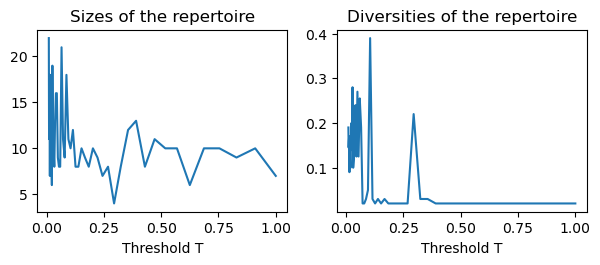

In [22]:
plt.figure(figsize=viz.cm_to_inch((18,6))) 
plt.subplot(1, 2, 1) 
plt.plot(T_vec, sizes, label="sizes")
plt.title("Sizes of the repertoire")
plt.xlabel("Threshold T")
plt.subplot(1, 2, 2)
plt.plot(T_vec, diversities, label="diversities")
plt.title("Diversities of the repertoire")
plt.xlabel("Threshold T")

In [23]:
dict_with_all_datasets.keys()

dict_keys(['hcp_schaefer_100_dataset_gnm', 'hcp_schaefer_100_dataset', 'kaysons_generated_networks_diffusion', 'kaysons_generated_networks_propagation', 'kaysons_generated_networks_routing', 'kaysons_generated_networks_topology', 'suarez_MaMI_dataset', 'lexis_data_developing', 'lexis_data_young', 'lexis_data_aging', 'lexis_data_developing_consensus_per_age_1_year', 'lexis_data_young_consensus_per_age_1_year', 'lexis_data_aging_consensus_per_age_1_year', 'lexis_data_all_consensus_per_age_1_year', 'lexis_data_all_consensus_per_age_2_year'])

kaysons_generated_networks_diffusion 1
  Processing sample 1/1 for dataset 'kaysons_generated_networks_diffusion'
kaysons_generated_networks_propagation 1
  Processing sample 1/1 for dataset 'kaysons_generated_networks_propagation'
kaysons_generated_networks_routing 1
  Processing sample 1/1 for dataset 'kaysons_generated_networks_routing'
kaysons_generated_networks_topology 1
  Processing sample 1/1 for dataset 'kaysons_generated_networks_topology'
suarez_MaMI_dataset 5
  Processing sample 1/5 for dataset 'suarez_MaMI_dataset'
  Processing sample 2/5 for dataset 'suarez_MaMI_dataset'
  Processing sample 3/5 for dataset 'suarez_MaMI_dataset'
  Processing sample 4/5 for dataset 'suarez_MaMI_dataset'
  Processing sample 5/5 for dataset 'suarez_MaMI_dataset'
lexis_data_developing 5
  Processing sample 1/5 for dataset 'lexis_data_developing'
  Processing sample 2/5 for dataset 'lexis_data_developing'
  Processing sample 3/5 for dataset 'lexis_data_developing'
  Processing sample 4/5 for da

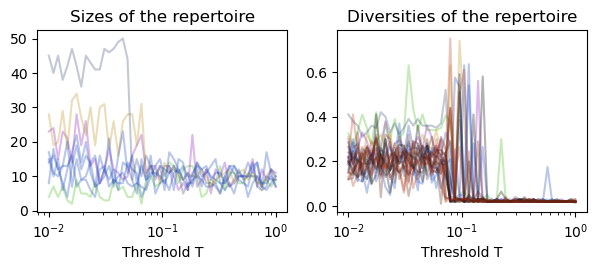

In [24]:
T_vec_arr = [] 
sizes_arr = []
diversities_arr = []
dataset_color_arr = []

# dataset_name = dataset_of_choice
datasets_to_look_at = [
    # 'hcp_schaefer_100_dataset_gnm', 
    # 'hcp_schaefer_100_dataset', 
    'kaysons_generated_networks_diffusion', 
    'kaysons_generated_networks_propagation', 
    'kaysons_generated_networks_routing', 
    'kaysons_generated_networks_topology', 
    'suarez_MaMI_dataset', 
    'lexis_data_developing', 
    'lexis_data_young', 
    'lexis_data_aging', 
    # 'lexis_data_developing_consensus_per_age_1_year', 
    # 'lexis_data_young_consensus_per_age_1_year', 
    # 'lexis_data_aging_consensus_per_age_1_year', 
    # 'lexis_data_all_consensus_per_age_1_year', 
    # 'lexis_data_all_consensus_per_age_2_year'
]

for dataset_name in datasets_to_look_at:
    length_dataset = len(dict_with_all_datasets[dataset_name])
    length_dataset = min(length_dataset, 5)  # Limit to the specified number of samples for each dataset
    print(dataset_name, length_dataset)
    for i in range(length_dataset):
        print(f"  Processing sample {i+1}/{length_dataset} for dataset '{dataset_name}'")
        T_vec = dict_with_all_datasets[dataset_name]["repertoire_sweep_T_vec"].to_numpy()[i]
        sizes = dict_with_all_datasets[dataset_name]["repertoire_sweep_sizes"].to_numpy()[i]
        diversities = dict_with_all_datasets[dataset_name]["repertoire_sweep_diversities"].to_numpy()[i]

        # from string to array: T_vec
        T_vec = np.array(re.findall(r"[-+]?\d*\.\d+|\d+", T_vec)).astype(float)
        sizes = np.array(re.findall(r"[-+]?\d*\.\d+|\d+", sizes)).astype(float)
        diversities = np.array(re.findall(r"[-+]?\d*\.\d+|\d+", diversities)).astype(float)

        T_vec_arr.append(T_vec)
        sizes_arr.append(sizes)
        diversities_arr.append(diversities)
        dataset_color_arr.append(COLOR_SCHEME[dataset_name])

alpha = 0.3
plt.figure(figsize=viz.cm_to_inch((18,6))) 
plt.subplot(1, 2, 1) 
for T_vec, sizes, color, dataset_name in zip(T_vec_arr, sizes_arr, dataset_color_arr, datasets_to_look_at):
    plt.plot(T_vec, sizes, label=dataset_name, color=color, alpha=alpha)
    # plt.plot(np.mean(T_vec, axis=1), np.mean(sizes, axis=1), # label=f"{dataset_name} mean", 
    #          color=color, alpha=1.0, linewidth=2)
plt.title("Sizes of the repertoire")
plt.xlabel("Threshold T")
plt.xscale("log")

handles, labels = plt.gca().get_legend_handles_labels()
# plt.legend(handles[::5], labels[::5])
# plt.legend()

plt.subplot(1, 2, 2)
for T_vec, diversities, color in zip(T_vec_arr, diversities_arr, dataset_color_arr):
    plt.plot(T_vec, diversities, label="diversities", color=color, alpha=alpha)
plt.title("Diversities of the repertoire")
plt.xlabel("Threshold T")
plt.xscale("log")



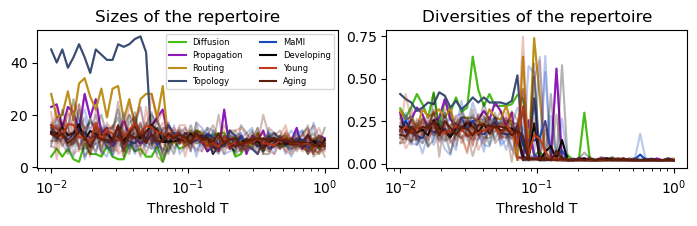

In [25]:
datasets_to_look_at = [
    'kaysons_generated_networks_diffusion', 
    'kaysons_generated_networks_propagation', 
    'kaysons_generated_networks_routing', 
    'kaysons_generated_networks_topology', 
    'suarez_MaMI_dataset', 
    'lexis_data_developing', 
    'lexis_data_young', 
    'lexis_data_aging', 
]

def parse_array(s):
    return np.array(re.findall(r"[-+]?\d*\.\d+|\d+", s), dtype=float)

def get_dataset_arrays(dataset_name, max_samples=5):
    df = dict_with_all_datasets[dataset_name]
    n = min(len(df), max_samples)
    return [
        (parse_array(df["repertoire_sweep_T_vec"].iloc[i]),
         parse_array(df["repertoire_sweep_sizes"].iloc[i]),
         parse_array(df["repertoire_sweep_diversities"].iloc[i]))
        for i in range(n)
    ]

fig, axes = plt.subplots(1, 2, figsize=viz.cm_to_inch((18, 6)))
axes[0].set(title="Sizes of the repertoire",       xlabel="Threshold T", xscale="log")
axes[1].set(title="Diversities of the repertoire", xlabel="Threshold T", xscale="log")

for dataset_name in datasets_to_look_at:
    color = COLOR_SCHEME[dataset_name]
    samples = get_dataset_arrays(dataset_name)
    T_all = np.array([T for T, _, _ in samples])
    sizes_all = np.array([s for _, s, _ in samples])
    divs_all  = np.array([d for _, _, d in samples])

    for T, sizes, divs in samples:
        axes[0].plot(T, sizes, color=color, alpha=0.3)
        axes[1].plot(T, divs,  color=color, alpha=0.3)

    # Mean per dataset
    axes[0].plot(T_all.mean(axis=0), sizes_all.mean(axis=0), color=color, label=LABEL_MAP[dataset_name])
    axes[1].plot(T_all.mean(axis=0), divs_all.mean(axis=0),  color=color)

axes[0].legend(ncol=2, fontsize=6) # bbox_to_anchor=(1, -0.5),  
            #    loc="upper center",
            #    ncol=3)
plt.tight_layout()
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/04_metastability/metastability_repertoire_sweep.pdf


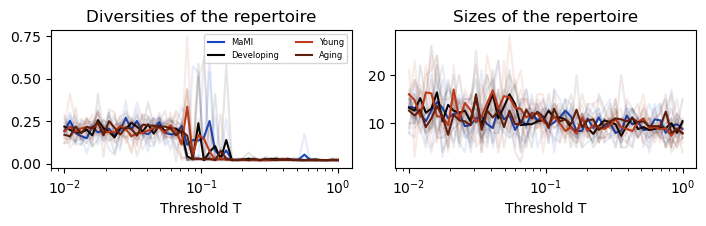

In [26]:
datasets_to_look_at = [
    # 'kaysons_generated_networks_diffusion', 
    # 'kaysons_generated_networks_propagation', 
    # 'kaysons_generated_networks_routing', 
    # 'kaysons_generated_networks_topology', 
    'suarez_MaMI_dataset', 
    'lexis_data_developing', 
    'lexis_data_young', 
    'lexis_data_aging', 
]

fig, axes = plt.subplots(1, 2, figsize=viz.cm_to_inch((18, 6)))
axes[1].set(title="Sizes of the repertoire",       xlabel="Threshold T", xscale="log")
axes[0].set(title="Diversities of the repertoire", xlabel="Threshold T", xscale="log")

alpha = 0.1

for dataset_name in datasets_to_look_at:
    color = COLOR_SCHEME[dataset_name]
    samples = get_dataset_arrays(dataset_name)
    T_all = np.array([T for T, _, _ in samples])
    sizes_all = np.array([s for _, s, _ in samples])
    divs_all  = np.array([d for _, _, d in samples])

    for T, sizes, divs in samples:
        axes[1].plot(T, sizes, color=color, alpha=alpha)
        axes[0].plot(T, divs,  color=color, alpha=alpha)

    # Mean per dataset
    axes[1].plot(T_all.mean(axis=0), 
                 sizes_all.mean(axis=0), 
                 color=color, label=LABEL_MAP[dataset_name])
    axes[0].plot(T_all.mean(axis=0), 
                 divs_all.mean(axis=0),  
                 color=color, label=LABEL_MAP[dataset_name])

# axes[1].legend(ncol=2, fontsize=6) # bbox_to_anchor=(1, -0.5),  
#             #    loc="upper center",
#             #    ncol=3)

axes[0].legend(ncol=2, fontsize=6) # bbox_to_anchor=(1, -0.5),   --- IGNORE ---
plt.tight_layout()

plt.savefig(output_folder / "metastability_repertoire_sweep.pdf", dpi=300)
print(output_folder / "metastability_repertoire_sweep.pdf")
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/04_metastability/metastability_repertoire_sweep_optimals.pdf


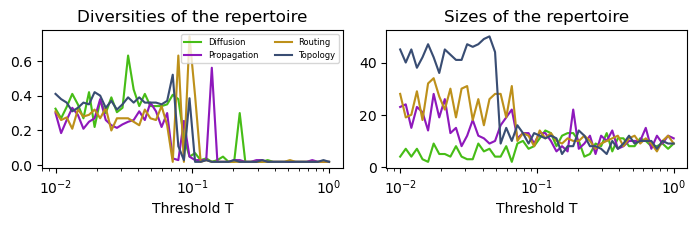

In [27]:
datasets_to_look_at = [
    'kaysons_generated_networks_diffusion', 
    'kaysons_generated_networks_propagation', 
    'kaysons_generated_networks_routing', 
    'kaysons_generated_networks_topology', 
    # 'suarez_MaMI_dataset', 
    # 'lexis_data_developing', 
    # 'lexis_data_young', 
    # 'lexis_data_aging', 
]

fig, axes = plt.subplots(1, 2, figsize=viz.cm_to_inch((18, 6)))
axes[1].set(title="Sizes of the repertoire",       xlabel="Threshold T", xscale="log")
axes[0].set(title="Diversities of the repertoire", xlabel="Threshold T", xscale="log")

alpha = 0.1

for dataset_name in datasets_to_look_at:
    color = COLOR_SCHEME[dataset_name]
    samples = get_dataset_arrays(dataset_name)
    T_all = np.array([T for T, _, _ in samples])
    sizes_all = np.array([s for _, s, _ in samples])
    divs_all  = np.array([d for _, _, d in samples])

    for T, sizes, divs in samples:
        axes[1].plot(T, sizes, color=color, alpha=alpha)
        axes[0].plot(T, divs,  color=color, alpha=alpha)

    # Mean per dataset
    axes[1].plot(T_all.mean(axis=0), 
                 sizes_all.mean(axis=0), 
                 color=color, label=LABEL_MAP[dataset_name])
    axes[0].plot(T_all.mean(axis=0), 
                 divs_all.mean(axis=0),  
                 color=color, label=LABEL_MAP[dataset_name])

# axes[1].legend(ncol=2, fontsize=6) # bbox_to_anchor=(1, -0.5),  
#             #    loc="upper center",
#             #    ncol=3)

axes[0].legend(ncol=2, fontsize=6) # bbox_to_anchor=(1, -0.5),   --- IGNORE ---
plt.tight_layout()

plt.savefig(output_folder / "metastability_repertoire_sweep_optimals.pdf", dpi=300)
print(output_folder / "metastability_repertoire_sweep_optimals.pdf")
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/04_metastability/metastability_repertoire_sweep.pdf


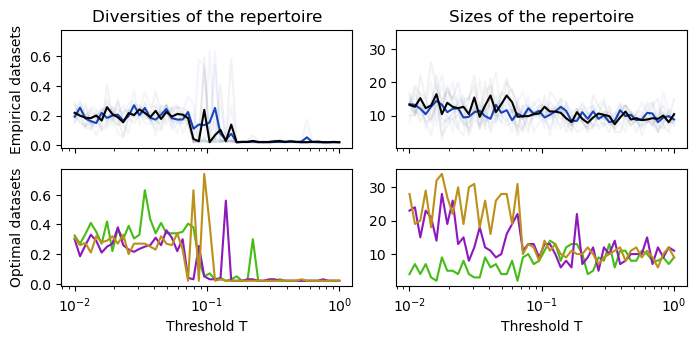

In [61]:
datasets_all = [
    'kaysons_generated_networks_diffusion',
    'kaysons_generated_networks_propagation',
    'kaysons_generated_networks_routing',
    # 'kaysons_generated_networks_topology',
    # 'suarez_MaMI_dataset',
    # 'lexis_data_developing',
    # 'lexis_data_young',
    # 'lexis_data_aging',
]
datasets_bio = [
    'suarez_MaMI_dataset',
    'lexis_data_developing',
    # 'lexis_data_young',
    # 'lexis_data_aging',
]

row_datasets = [datasets_bio, datasets_all]
col_keys     = ["divs", "sizes"]
row_labels   = ["Empirical datasets", "Optimal datasets"]
col_titles   = ["Diversities of the repertoire", "Sizes of the repertoire"]
alphas       = [0.05, 0.05]

fig, axes = plt.subplots(
    2, 2,
    figsize=viz.cm_to_inch((18, 9)),
    sharex="col",   # share x-axis within each column
    sharey="col",   # share y-axis within each column
)

for row_idx, (datasets_to_look_at, alpha) in enumerate(zip(row_datasets, alphas)):
    for col_idx in range(2):
        ax = axes[row_idx, col_idx]
        ax.set_xscale("log")

        # Row label on the left-most axis
        if col_idx == 0:
            ax.set_ylabel(row_labels[row_idx]) # , fontsize=7, labelpad=4)

        for dataset_name in datasets_to_look_at:
            color   = COLOR_SCHEME[dataset_name]
            samples = get_dataset_arrays(dataset_name)
            T_all     = np.array([T for T, _, _ in samples])
            sizes_all = np.array([s for _, s, _ in samples])
            divs_all  = np.array([d for _, _, d in samples])

            values_all = sizes_all if col_idx == 1 else divs_all

            for T, sizes, divs in samples:
                vals = sizes if col_idx == 1 else divs
                ax.plot(T, vals, color=color, alpha=alpha) # , linewidth=0.5)

            ax.plot(
                T_all.mean(axis=0),
                values_all.mean(axis=0),
                color=color,
                label=LABEL_MAP[dataset_name],
                # linewidth=1.5,
            )

        # # Legend only on bottom-left to avoid clutter
        # if row_idx == 1 and col_idx == 0:
        #     ax.legend(ncol=2, fontsize=6)

# Column titles on the top row only
for col_idx, title in enumerate(col_titles):
    axes[0, col_idx].set_title(title) # , fontsize=8)

# Shared x-label: only on bottom row (top row ticks are hidden via sharex)
for col_idx in range(2):
    axes[1, col_idx].set_xlabel("Threshold T") # , fontsize=7)

plt.tight_layout()
plt.savefig(output_folder / "metastability_repertoire_sweep.pdf", dpi=300)
print(output_folder / "metastability_repertoire_sweep.pdf")
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/04_metastability/metastability_repertoire_sweep_legend.pdf


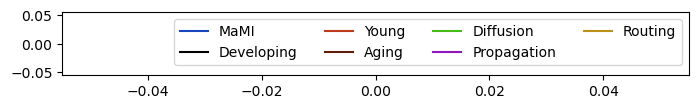

In [31]:
datasets_to_look_at = [
    'suarez_MaMI_dataset', 
    'lexis_data_developing', 
    'lexis_data_young', 
    'lexis_data_aging', 
    
    'kaysons_generated_networks_diffusion', 
    'kaysons_generated_networks_propagation', 
    'kaysons_generated_networks_routing', 
    # 'kaysons_generated_networks_topology', 
]

# Plot a legend separately, so that it is more readable. We can use the same colors and labels as before, but just plot empty lines with the correct colors and labels to create a legend.
plt.figure(figsize=viz.cm_to_inch((18, 3)))
for dataset_name in datasets_to_look_at:
    color = COLOR_SCHEME[dataset_name]
    plt.plot([], [], color=color, label=LABEL_MAP[dataset_name])
    
plt.legend(ncol=4) # , fontsize=6) # bbox_to_anchor=(1, -0.5),  
            #    loc="upper center",
            #    ncol=3)
plt.tight_layout()
plt.savefig(output_folder / "metastability_repertoire_sweep_legend.pdf", bbox_inches="tight", dpi=300)
print(output_folder / "metastability_repertoire_sweep_legend.pdf")
plt.show()

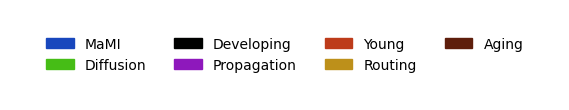

In [34]:
datasets_to_look_at = [
    'suarez_MaMI_dataset', 
    'kaysons_generated_networks_diffusion', 
    'lexis_data_developing', 
    'kaysons_generated_networks_propagation', 
    'lexis_data_young', 
    'kaysons_generated_networks_routing', 
    'lexis_data_aging',     
]

# # Build handles/labels without any axes
# handles = []
# for dataset_name in datasets_to_look_at:
#     handles.append(
#         plt.Line2D([0], [0], color=COLOR_SCHEME[dataset_name], label=LABEL_MAP[dataset_name])
#     )

# fig, ax = plt.subplots(figsize=viz.cm_to_inch((18, 3)))
# legend = ax.legend(handles=handles, ncol=4, loc="center")
# ax.axis("off")                          # hide axes entirely

# # Crop figure to the legend bounding box only
# fig.canvas.draw()
# bbox = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
# fig.savefig(output_folder / "metastability_repertoire_sweep_legend.pdf",
#             bbox_inches=bbox, dpi=300)
# plt.show()

import matplotlib.patches as mpatches

handles = []
for dataset_name in datasets_to_look_at:
    handles.append(
        mpatches.Patch(color=COLOR_SCHEME[dataset_name], label=LABEL_MAP[dataset_name])
    )

fig, ax = plt.subplots(figsize=viz.cm_to_inch((18, 3)))
legend = ax.legend(handles=handles, ncol=4, loc="center", frameon=False)
ax.axis("off")

fig.canvas.draw()
bbox = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
fig.savefig(output_folder / "metastability_repertoire_sweep_legend.pdf",
            bbox_inches=bbox, dpi=300)
plt.show()

# Old

In [12]:
dict_with_all_datasets["lexis_data_aging"]["repertoire_sweep_T_vec"].to_numpy()[0]

'[0.01, 0.010985411419875584, 0.012067926406393288, 0.013257113655901088, 0.014563484775012436, 0.015998587196060583, 0.017575106248547922, 0.019306977288832496, 0.021209508879201904, 0.023299518105153717, 0.025595479226995357, 0.028117686979742307, 0.030888435964774818, 0.03393221771895328, 0.0372759372031494, 0.040949150623804234, 0.04498432668969444, 0.04941713361323833, 0.054286754393238594, 0.05963623316594643, 0.0655128556859551, 0.07196856730011521, 0.07906043210907697, 0.08685113737513525, 0.09540954763499938, 0.10481131341546858, 0.1151395399326447, 0.12648552168552957, 0.13894954943731375, 0.15264179671752334, 0.16768329368110074, 0.18420699693267154, 0.20235896477251566, 0.22229964825261944, 0.2442053094548651, 0.2682695795279725, 0.29470517025518095, 0.32374575428176433, 0.35564803062231287, 0.3906939937054615, 0.42919342601287763, 0.47148663634573923, 0.517947467923121, 0.5689866029018296, 0.6250551925273969, 0.6866488450042998, 0.7543120063354615, 0.8286427728546842, 0.91

Text(0, 0.5, 'diversities')

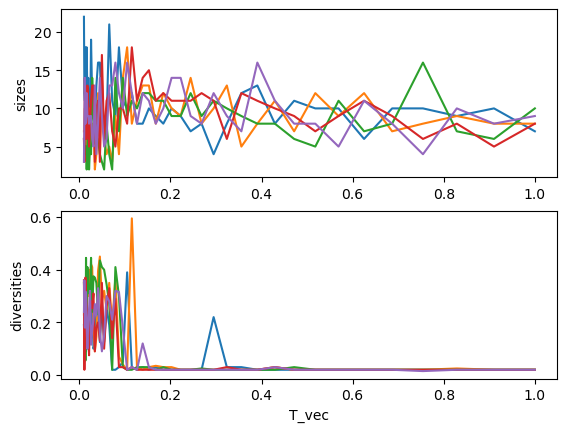

In [13]:
for i in range(5): 
    T_vec = dict_with_all_datasets[dataset_of_choice]["repertoire_sweep_T_vec"][i]
    sizes = dict_with_all_datasets[dataset_of_choice]["repertoire_sweep_sizes"][i]
    diversities = dict_with_all_datasets[dataset_of_choice]["repertoire_sweep_diversities"][i]

    # from string to array: T_vec
    T_vec = np.array(re.findall(r"[-+]?\d*\.\d+|\d+", T_vec)).astype(float)
    sizes = np.array(re.findall(r"[-+]?\d*\.\d+|\d+", sizes)).astype(float)
    diversities = np.array(re.findall(r"[-+]?\d*\.\d+|\d+", diversities)).astype(float)
    
    plt.subplot(2,1,1) 
    plt.plot(T_vec, sizes, label="sizes")
    plt.subplot(2, 1, 2)
    plt.plot(T_vec, diversities, label="diversities")

plt.xlabel("T_vec")
plt.subplot(2,1,1) 
plt.ylabel("sizes")
plt.subplot(2, 1, 2)
plt.ylabel("diversities")

IndexError: index 8 is out of bounds for axis 0 with size 8

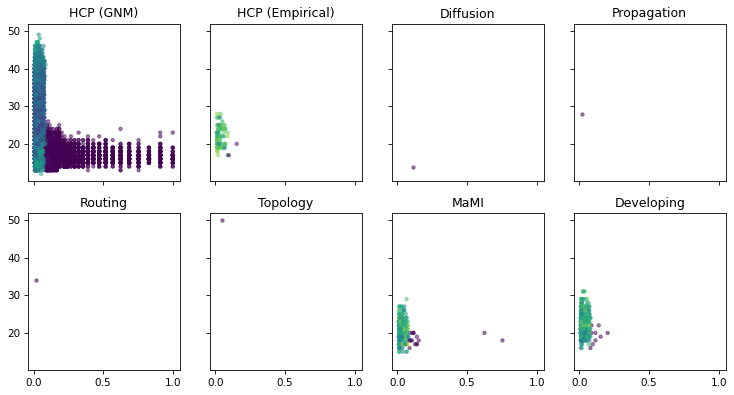

In [16]:
fig, axs = plt.subplots(2,4, figsize=(12,6), sharex=True, sharey=True, dpi=75)
axs = axs.flatten()
for i, (dataset, df) in enumerate(dict_with_all_datasets.items()):
    ax = axs[i]
    ax.scatter(df["repertoire_sweep_T_critical"], df["repertoire_sweep_size_critical"], c=df["repertoire_sweep_diversity_critical"], 
            s=10, alpha=0.5)
    ax.set_title(LABEL_MAP[dataset])
plt.xlabel("T_critical")
plt.ylabel("size_critical")
plt.suptitle("Critical size vs T, colored by diversity")
plt.tight_layout()

# remove unused subplots
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

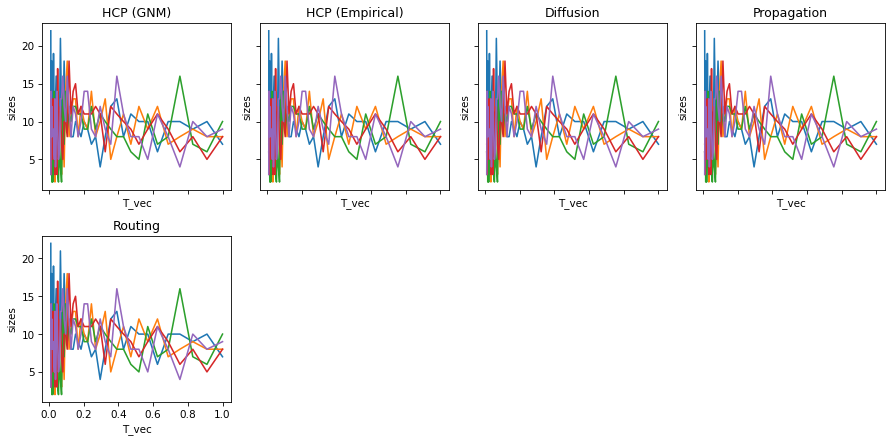

In [ ]:
fig, axs = plt.subplots(2,4, figsize=(12,6), sharex=True, sharey=True, dpi=75)
axs = axs.flatten()
for i, (dataset, df) in enumerate(dict_with_all_datasets.items()):
    ax = axs[i]
    
    for i in range(5): 
        T_vec = dict_with_all_datasets[dataset_of_choice]["repertoire_sweep_T_vec"][i]
        sizes = dict_with_all_datasets[dataset_of_choice]["repertoire_sweep_sizes"][i]

        # from string to array: T_vec
        T_vec = np.array(re.findall(r"[-+]?\d*\.\d+|\d+", T_vec)).astype(float)
        sizes = np.array(re.findall(r"[-+]?\d*\.\d+|\d+", sizes)).astype(float)

        ax.plot(T_vec, sizes, label="sizes")

    ax.set_xlabel("T_vec")
    ax.set_ylabel("sizes")
    ax.set_title(LABEL_MAP[dataset])

# remove unused subplots
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])
    
plt.tight_layout()

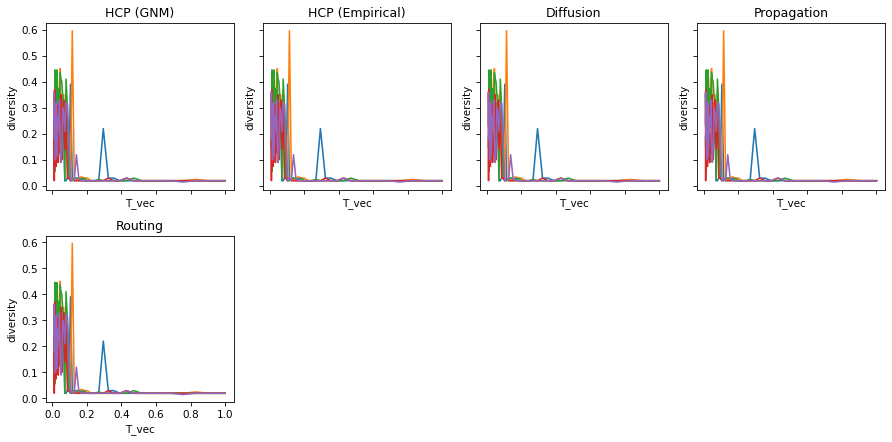

In [ ]:
fig, axs = plt.subplots(2,4, figsize=(12,6), sharex=True, sharey=True, dpi=75)
axs = axs.flatten()
for i, (dataset, df) in enumerate(dict_with_all_datasets.items()):
    ax = axs[i]
    
    for i in range(5): 
        T_vec = dict_with_all_datasets[dataset_of_choice]["repertoire_sweep_T_vec"][i]
        sizes = dict_with_all_datasets[dataset_of_choice]["repertoire_sweep_diversities"][i]

        # from string to array: T_vec
        T_vec = np.array(re.findall(r"[-+]?\d*\.\d+|\d+", T_vec)).astype(float)
        sizes = np.array(re.findall(r"[-+]?\d*\.\d+|\d+", sizes)).astype(float)

        ax.plot(T_vec, sizes, label="diversity")

    ax.set_xlabel("T_vec")
    ax.set_ylabel("diversity")
    ax.set_title(LABEL_MAP[dataset])

# remove unused subplots
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])
    
plt.tight_layout()